# Introduction
This project is part of **Module 17** of the **Berkeley PTrofessional Certificate in Machine Learning and Artificial Intelligence**.

The objective is to evaluate and compare the performance of four supervised learning algorithms—**K-Nearest Neighbors (KNN), Logistic Regression, Decision Trees, and Support Vector Machines (SVM)** using the Bank Marketing dataset. The models are trained to predict whether a client will subscribe to a term deposit following a telephone marketing campaign.

The project follows a structured machine learning workflow including **data exploration, preprocessing, feature engineering, model training, hyperparameter tuning, and performance evaluation** using metrics such as Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time.

# Data Preparation / Feature Engineering

In [1]:
import time

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('data/bank-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


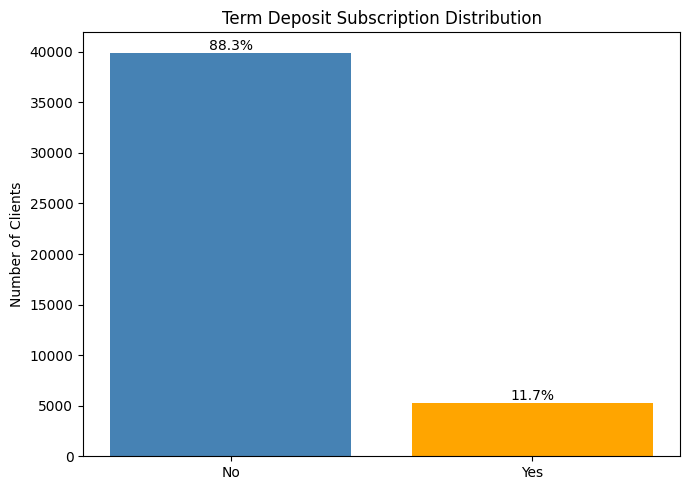

In [5]:
counts = df["y"].value_counts()
percentages = df["y"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    ["No", "Yes"],
    counts.values,
    color=["steelblue", "orange"]
)

for i, bar in enumerate(bars):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{percentages.iloc[i]:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title("Term Deposit Subscription Distribution")
ax.set_ylabel("Number of Clients")

plt.tight_layout()
plt.show()

This plot indicates that dataset is imbalanced because the majority class (No) is about 7.5 times larger than the minority class (Yes)

## Understanding the Features

| Group                                           | Features                                                      |
| ----------------------------------------------- | ------------------------------------------------------------- |
| **Client Demographics & Financial Information** | age, job, marital, education, default, balance, housing, loan |
| **Current Campaign Contact Information**        | contact, day, month, duration                                 |
| **Previous Campaign History**                   | campaign, pdays, previous, poutcome                           |
| **Target Variable**                             | y                                                             |


| #  | Feature       | Type            | Description                                                                 | Possible Values                                                                                                                      |
| :- | :------------ | :-------------- | :-------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------- |
| 1  | **age**       | Numeric         | Age of the client                                                           | —                                                                                                                                    |
| 2  | **job**       | Categorical     | Type of job                                                                 | admin., unknown, unemployed, management, housemaid, entrepreneur, student, blue-collar, self-employed, retired, technician, services |
| 3  | **marital**   | Categorical     | Marital status                                                              | married, divorced (includes widowed), single                                                                                         |
| 4  | **education** | Categorical     | Education level                                                             | unknown, secondary, primary, tertiary                                                                                                |
| 5  | **default**   | Binary          | Has credit in default?                                                      | yes, no                                                                                                                              |
| 6  | **balance**   | Numeric         | Average yearly balance (EUR)                                                | —                                                                                                                                    |
| 7  | **housing**   | Binary          | Has a housing loan?                                                         | yes, no                                                                                                                              |
| 8  | **loan**      | Binary          | Has a personal loan?                                                        | yes, no                                                                                                                              |
| 9  | **contact**   | Categorical     | Communication type used for the last contact                                | unknown, telephone, cellular                                                                                                         |
| 10 | **day**       | Numeric         | Day of the month of the last contact                                        | 1–31                                                                                                                                 |
| 11 | **month**     | Categorical     | Month of the last contact                                                   | jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec                                                                           |
| 12 | **duration**  | Numeric         | Duration of the last contact (seconds)                                      | —                                                                                                                                    |
| 13 | **campaign**  | Numeric         | Number of contacts during the current campaign (including the last contact) | —                                                                                                                                    |
| 14 | **pdays**     | Numeric         | Days since the client was last contacted in a previous campaign             | -1 = not previously contacted                                                                                                        |
| 15 | **previous**  | Numeric         | Number of contacts before the current campaign                              | —                                                                                                                                    |
| 16 | **poutcome**  | Categorical     | Outcome of the previous marketing campaign                                  | unknown, other, failure, success                                                                                                     |
| 17 | **y**         | Binary (Target) | Has the client subscribed to a term deposit?                                | yes, no                                                                                                                              |


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

The dataset has no missing values.

Separate features and target

In [7]:
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})

## Feature Engineering for the Bank Marketing Dataset

The following features were engineered to enhance the predictive power of the models:

- **previously_contacted**: Indicates whether the client was contacted in a previous marketing campaign (`pdays != -1`).
- **balance_log**: Log-transformed account balance to reduce skewness and lessen the impact of extreme outliers.
- **debt_count**: Total number of active loans, calculated as the sum of housing and personal loans.
- **positive_balance**: Binary indicator showing whether the client has a positive account balance.
- **age_group**: Age grouped into life-stage categories (`young`, `adult`, `middle`, `senior`, `retired`) to capture potential non-linear age effects.

In [8]:
def add_features(X):
    X = X.copy()

    # Client was contacted before (pdays = -1 means never contacted)
    X["previously_contacted"] = (X["pdays"] != -1).astype(int)

    # Log-transform balance while preserving sign
    # Reduces skewness and makes extreme balances less influential
    X["balance_log"] = (
        np.sign(X["balance"]) * np.log1p(np.abs(X["balance"]))
    )

    # Number of active debts:
    # 0 = no loans
    # 1 = one loan (housing or personal)
    # 2 = both housing and personal loans
    X["debt_count"] = (
        (X["housing"] == "yes").astype(int)
        + (X["loan"] == "yes").astype(int)
    )

    # Binary indicator of financial status
    # 1 = positive balance, 0 = zero or negative balance
    X["positive_balance"] = (X["balance"] > 0).astype(int)

    # Group clients into age categories
    # May capture non-linear relationships between age and subscription behavior
    X["age_group"] = pd.cut(
        X["age"],
        bins=[0, 25, 35, 50, 65, 100],
        labels=["young", "adult", "middle", "senior", "retired"]
    )

    return X

In [9]:
numeric_features = [
    "age",
    "balance",
    "balance_log",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "debt_count",
    "positive_balance",
    "previously_contacted"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "age_group"
]

## Splitting data to Train/Test subsets

The dataset was split into training and testing subsets using a stratified sampling strategy **(stratify=y)** to preserve the original class distribution of the target variable and ensure a representative evaluation set.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline Models

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [13]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("feature_engineering", FunctionTransformer(add_features, validate=False)),
        ("preprocessing", preprocessor),
        ("model", model)
    ])

# Baseline Models Comparison

In [14]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Train Accuracy": scores["train_accuracy"].mean(),
        "Test Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Fit Time": scores["fit_time"].mean(),
        "Score Time": scores["score_time"].mean()
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC,Fit Time,Score Time
1,Logistic Regression,0.902808,0.901709,0.649533,0.348151,0.453050,0.908946,0.075567,0.024487
3,SVM,0.913376,0.902262,0.668561,0.326642,0.438684,0.903077,27.427315,3.387929
0,KNN,0.920648,0.893967,0.583007,0.329712,0.421129,0.821715,0.053410,0.978553
2,Decision Tree,1.000000,0.875664,0.469340,0.478139,0.473617,0.703233,0.227860,0.024407


# Hyperparameter Tuning

## Logistic Regression

In [15]:
# Rebuild the logistic regression pipeline model step
pipelines["Logistic Regression"].set_params(
    model=LogisticRegression(
        solver="saga",
        max_iter=5000,
        random_state=42
    )
)

param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=pipelines["Logistic Regression"],
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr.fit(X_train, y_train)

print("Best parameters:")
print(grid_lr.best_params_)

print("Best CV score:")
print(grid_lr.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 1}
Best CV score:
0.9121789220549357


In [16]:
best_lr = grid_lr.best_estimator_

In [17]:
preprocessor = best_lr.named_steps['preprocessing']
lr_model = best_lr.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})

importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance['Odds_Ratio'] = np.exp(importance['Coefficient'])

importance.sort_values(
    'Abs_Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
53,cat__poutcome_success,2.142097,2.142097,8.517281
46,cat__month_mar,1.600041,1.600041,4.953238
4,num__duration,1.518957,1.518957,4.567461
38,cat__contact_unknown,-1.472025,1.472025,0.229460
43,cat__month_jan,-1.205287,1.205287,0.299606
49,cat__month_oct,1.198944,1.198944,3.316613
44,cat__month_jul,-0.981054,0.981054,0.374916
48,cat__month_nov,-0.928822,0.928822,0.395019
50,cat__month_sep,0.827434,0.827434,2.287441
40,cat__month_aug,-0.827297,0.827297,0.437229


## Decision Tree

In [18]:
dt_pipeline = pipelines["Decision Tree"]

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 7, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20, 50],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__class_weight": [None, "balanced"],
    "model__ccp_alpha": [0.0, 0.0001, 0.001, 0.01]
}

grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Best parameters:")
print(grid_dt.best_params_)

print("Best CV score:")
print(grid_dt.best_score_)

Fitting 5 folds for each of 2800 candidates, totalling 14000 fits
Best parameters:
{'model__ccp_alpha': 0.001, 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
Best CV score:
0.909892084087011


In [19]:
best_dt = grid_dt.best_estimator_

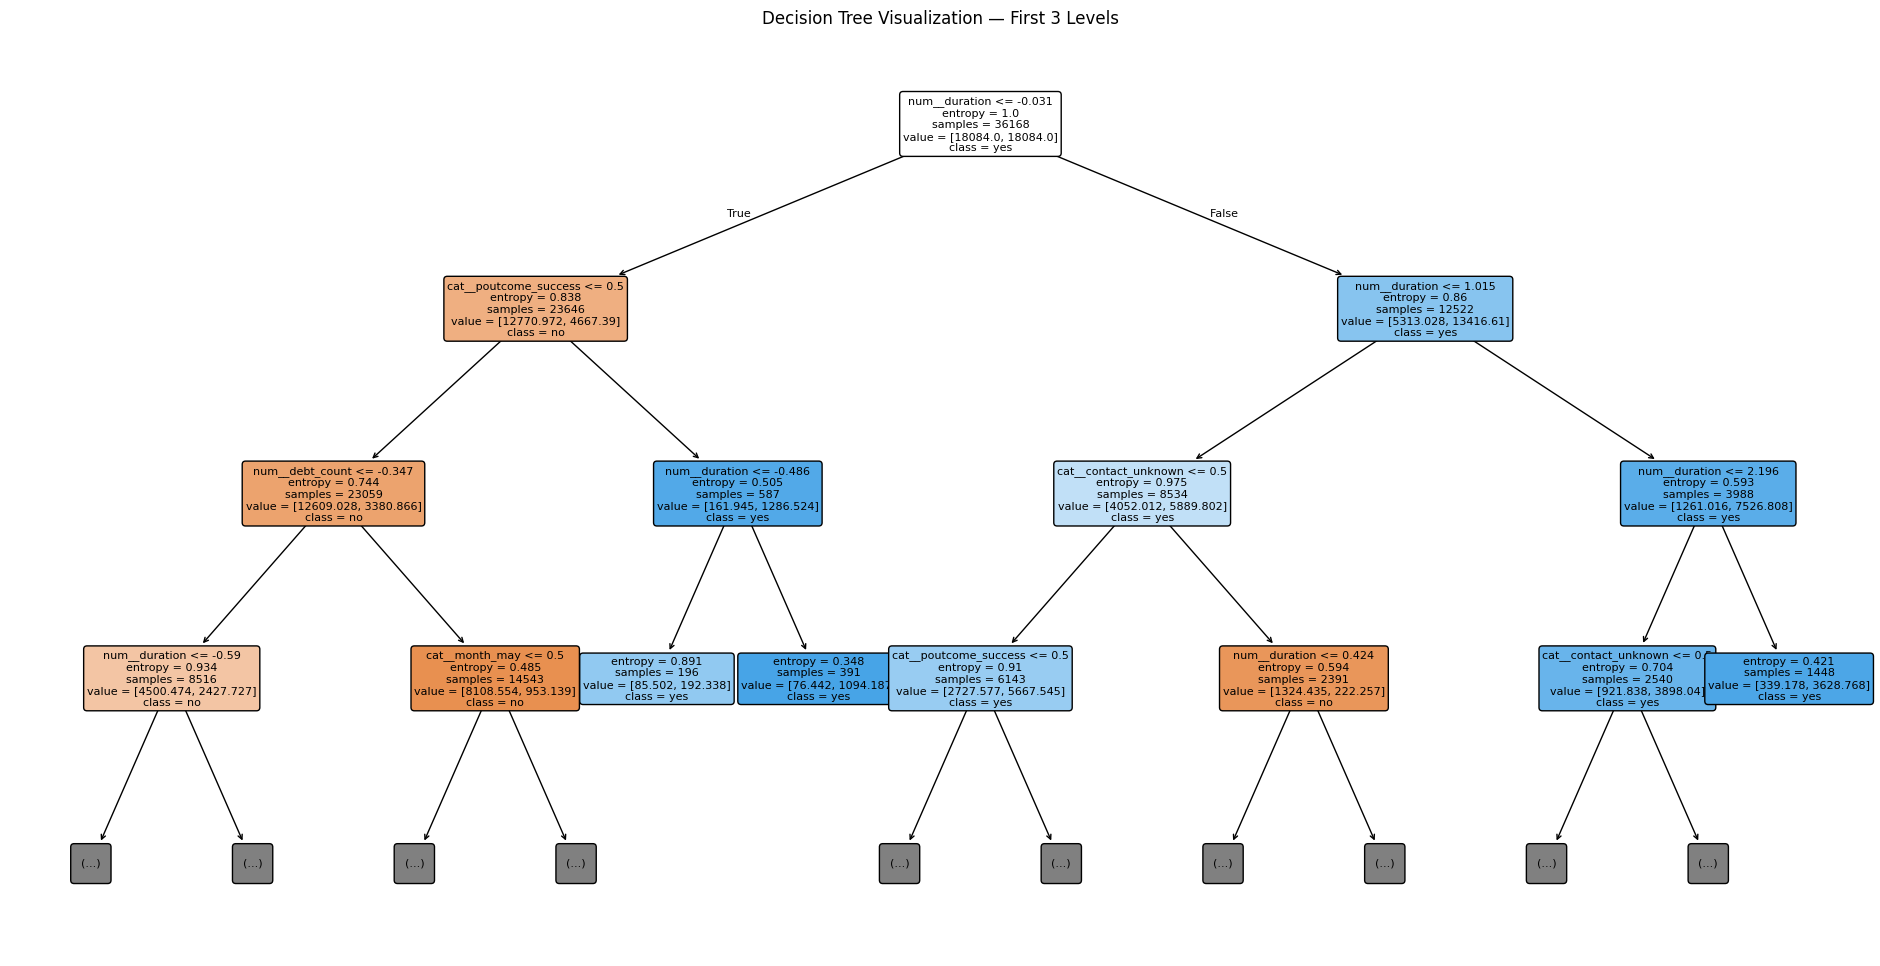

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_dt = grid_dt.best_estimator_

dt_model = best_dt.named_steps["model"]

feature_names = best_dt.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization — First 3 Levels")
plt.show()

# k-Nearest Neighbors

In [21]:
param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

grid_knn = GridSearchCV(
    pipelines["KNN"],
    param_grid_knn,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print("Best parameters:")
print(grid_knn.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_knn.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters:
{'model__n_neighbors': 31, 'model__p': 2, 'model__weights': 'distance'}

Best CV ROC-AUC:
0.8927934315980053


In [22]:
best_knn = grid_knn.best_estimator_

# SVM

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_svm = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": [None, "balanced"]
    }
]

"""
grid_svm = GridSearchCV(
    pipelines["SVM"],
    param_grid_svm,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)
"""

random_svm = RandomizedSearchCV(
    pipelines["SVM"],
    param_distributions=param_grid_svm,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_svm.fit(X_train, y_train)

print("Best parameters:")
print(random_svm.best_params_)

print("\nBest CV ROC-AUC:")
print(random_svm.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV ROC-AUC:
0.9251569766856104


In [28]:
best_svm = random_svm.best_estimator_

# Tuned Results

In [29]:
tuned_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svm
}

tuned_results = []

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    tuned_results.append({
        "Model": name,
        "Train Accuracy": scores["train_accuracy"].mean(),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Fit Time": scores["fit_time"].mean(),
        "Score Time": scores["score_time"].mean()
    })

tuned_comparison_df = (
    pd.DataFrame(tuned_results)
      .sort_values("ROC-AUC", ascending=False)
      .round(4)
)

tuned_comparison_df

,Model,Train Accuracy,CV Accuracy,Precision,Recall,F1,ROC-AUC,Fit Time,Score Time
3,SVM,0.8490,0.8399,0.4131,0.8745,0.5611,0.9248,52.9327,5.3931
0,Logistic Regression,0.8456,0.8447,0.4171,0.8227,0.5535,0.9120,5.6448,0.0240
2,Decision Tree,0.8200,0.8147,0.3776,0.8747,0.5263,0.9086,0.1685,0.0240
1,KNN,1.0000,0.8965,0.6501,0.2512,0.3622,0.8907,0.0538,1.0746


# Model selection and final recommendations

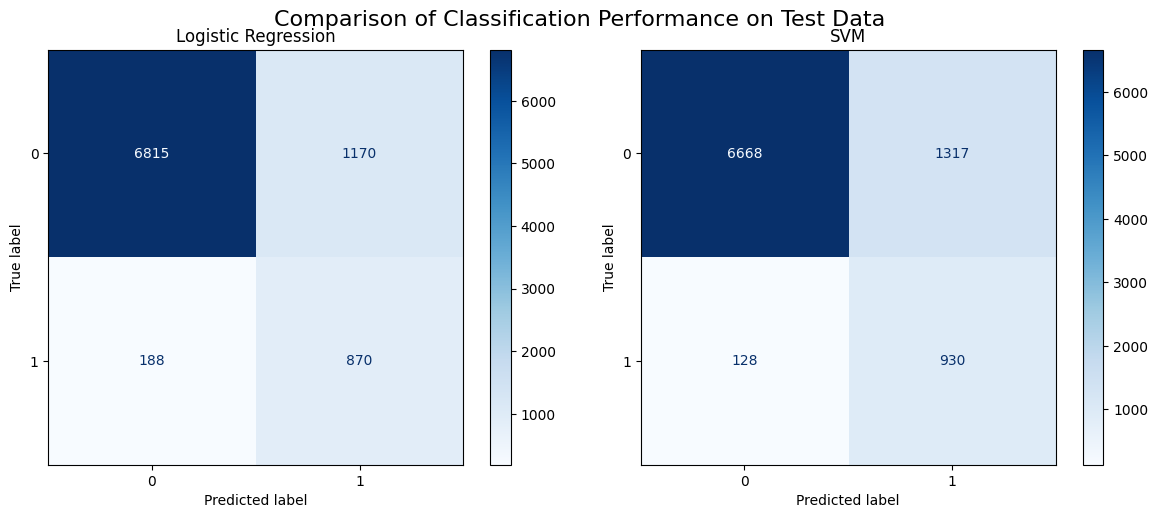

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Fit Time (s),Predict Time (s)
1,SVM,0.8402,0.4139,0.8790,0.5628,0.9250,69.9449,3.7789
0,Logistic Regression,0.8498,0.4265,0.8223,0.5617,0.9087,8.4810,0.0102


In [30]:
models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm
}

final_results = []

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Comparison of Classification Performance on Test Data",
    fontsize=16
)

for ax, (name, model) in zip(axes, models.items()):

    # Fit time
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    # Prediction time
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start

    # Probability for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Save metrics
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Fit Time (s)": fit_time,
        "Predict Time (s)": predict_time
    })

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

final_test_df = (
    pd.DataFrame(final_results)
      .sort_values("ROC-AUC", ascending=False)
      .round(4)
)

final_test_df

# Conclusions

## Final Model Selection

The tuned SVM achieved the best overall predictive performance with a ROC-AUC score of 0.925 and the highest recall (0.879), demonstrating superior ability to identify clients likely to subscribe to a term deposit.

However, Logistic Regression achieved comparable F1-score (0.562 vs. 0.563) and slightly higher accuracy (0.85 vs. 0.84) while requiring approximately 8 times less training time.

Therefore:

- **SVM** is the best-performing model in terms of predictive power.
- **Logistic Regression** provides the best trade-off between performance, interpretability, and computational efficiency.

For production deployment, Logistic Regression may be preferred due to its simplicity and significantly lower computational cost, while SVM remains the strongest model in terms of pure predictive performance.